# ASSIGNMENT 2: MARKET SEGMENTATION & CONJOINT ANALYSIS
Bowen de Gouw U02747415

In [15]:
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


# PART I: SEGMENTATION

In [16]:
# A.
days25 = pd.read_csv('days25.csv')

In [17]:
days25.head()

,Day_ID,Day_of_Week,season_week_rel,Is_Holiday,Total_Visitors,Passholder_Percentage,Day_Tickets_Sold,Avg_Ticket_Price,Gate_Revenue,Revenue_Food,Revenue_Merch,Revenue_Arcade,Total_Revenue,Total_Labor_Hours,International_Visitors,High_Temperature,Weather_Type,Is_Special_Event,Per_Capita_Spend
0,1,Monday,1,1,1769,48.65,908,77.42,70297.36,40521.91,15881.290,3195.46,129896.02,238.1,114.0,74.6,Thunderstorms,0,73.43
1,2,Tuesday,1,0,1717,60.58,677,69.80,47254.60,35298.92,15882.665,2977.63,101812.36,253.4,255.0,74.0,Partly Cloudy,0,59.30
2,3,Wednesday,1,0,1600,30.84,1107,70.09,77589.63,36495.95,14954.040,2683.58,131723.20,213.3,160.0,76.8,Partly Cloudy,0,82.33
3,4,Thursday,1,0,1037,19.02,840,72.30,60732.00,22486.65,9517.060,1831.98,94567.69,192.7,83.0,75.4,Showers,0,91.19
4,5,Friday,1,0,1671,66.18,565,68.11,38482.15,40705.15,15727.620,3115.94,98030.86,235.9,158.0,80.7,Partly Cloudy,0,58.67


In [18]:
days25.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Day_ID                  99 non-null     int64  
 1   Day_of_Week             99 non-null     object 
 2   season_week_rel         99 non-null     int64  
 3   Is_Holiday              99 non-null     int64  
 4   Total_Visitors          99 non-null     int64  
 5   Passholder_Percentage   99 non-null     float64
 6   Day_Tickets_Sold        99 non-null     int64  
 7   Avg_Ticket_Price        99 non-null     float64
 8   Gate_Revenue            99 non-null     float64
 9   Revenue_Food            99 non-null     float64
 10  Revenue_Merch           99 non-null     float64
 11  Revenue_Arcade          99 non-null     float64
 12  Total_Revenue           99 non-null     float64
 13  Total_Labor_Hours       99 non-null     float64
 14  International_Visitors  99 non-null     floa

**Numerical Variables:** Total Visitors, Passholder Percentage, Days Ticket Sold, Average Ticket Price, Gate Revenue, Food Revenue, Merch Revenue, Arcade Revenue, Total Revenue, Total Labor Hours, International Visitors, Highest Temperature, Per Capita Spend

**Categorical Variables:** Day ID, Day of the Week, Season Week, Holiday, Weather Type, Special Event

We are unable to use categorcal data unputs in a k-means model as the model is created and relies on Euclidean Distnce, which assumes that the data is continunous and on a meaningful scale so these values can be accurately compared and calculated to form the euclidean distances, and clusters.

In [19]:
#B.
days25.describe()

,Day_ID,season_week_rel,Is_Holiday,Total_Visitors,Passholder_Percentage,Day_Tickets_Sold,Avg_Ticket_Price,Gate_Revenue,Revenue_Food,Revenue_Merch,Revenue_Arcade,Total_Revenue,Total_Labor_Hours,International_Visitors,High_Temperature,Is_Special_Event,Per_Capita_Spend
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,50.000000,7.575758,0.030303,1870.707071,41.973232,1098.292929,70.439697,79484.778182,54715.882626,18691.392273,4450.617879,147911.785253,256.535354,178.464646,77.126263,0.151515,76.930808
std,28.722813,4.100998,0.172292,641.078735,15.581994,466.750518,10.680450,37053.465251,97737.730733,8077.026667,2992.738130,62854.729274,47.232843,85.522800,13.975537,0.360375,12.582334
min,1.000000,1.000000,0.000000,-50.000000,11.720000,322.000000,-25.000000,22350.020000,22486.650000,9517.060000,1831.980000,63247.570000,192.700000,-10.000000,63.800000,0.000000,51.630000
25%,25.500000,4.000000,0.000000,1482.000000,28.895000,771.000000,68.250000,53853.740000,33291.365000,13492.635000,2693.595000,103186.105000,222.400000,117.500000,70.850000,0.000000,68.575000
50%,50.000000,8.000000,0.000000,1704.000000,40.900000,995.000000,70.480000,70272.360000,38054.660000,15882.665000,3026.520000,129433.130000,243.500000,158.000000,74.800000,0.000000,77.500000
75%,74.500000,11.000000,0.000000,2080.000000,54.590000,1411.000000,73.735000,103147.720000,55612.790000,22567.790000,5419.410000,184173.685000,272.000000,232.500000,81.350000,0.000000,84.385000
max,99.000000,15.000000,1.000000,3938.000000,73.650000,3029.000000,82.280000,242229.130000,999999.990000,51601.440000,15755.610000,423019.370000,435.400000,560.000000,200.000000,1.000000,110.860000


The describe function helps gain a sense of the data as it produces summary statistics that can be used to gain a baseline understanding and analysis of the data. It is important for any analyst to understand the baseline metrics before building any additional models as it gives them a better sense for what the results may produce and to evauate performance/effectiveness. However, it is important to note that it is not always useful - for some variables that are numerical references of categorical variables, making it vital to understand the structure of your data.

In [20]:
#C.
days25.isnull().sum()

,0
Day_ID,0
Day_of_Week,0
season_week_rel,0
Is_Holiday,0
Total_Visitors,0
Passholder_Percentage,0
Day_Tickets_Sold,0
Avg_Ticket_Price,0
Gate_Revenue,0
Revenue_Food,0


There are no missing values in this dataset.

In [21]:
days25.International_Visitors.value_counts().sort_index(ascending=True)

,count
International_Visitors,
-10.0,1
59.0,1
65.0,1
66.0,1
74.0,1
...,...
359.0,1
366.0,1
371.0,1


In [22]:
days25.Revenue_Food.value_counts().sort_index(ascending=True)

,count
Revenue_Food,
22486.65,1
22510.15,1
24020.96,1
25637.54,1
25824.84,1
...,...
96183.58,1
97481.74,1
104871.10,1


In [23]:
days25.High_Temperature.value_counts().sort_index(ascending=True)

,count
High_Temperature,
63.8,1
65.2,1
65.5,1
66.6,1
66.8,1
...,...
86.4,1
86.8,1
86.9,1


In [24]:
days25.Avg_Ticket_Price.value_counts().sort_index(ascending=True)

,count
Avg_Ticket_Price,
-25.00,1
61.92,1
62.74,1
64.77,1
65.51,1
...,...
81.06,1
81.40,1
81.56,1


In [25]:
days25.Total_Visitors.value_counts().sort_index(ascending=True)

,count
Total_Visitors,
-50,1
1037,1
1124,1
1125,1
1154,1
...,...
3181,1
3205,1
3447,1


Impossible Values
- International Vistors entry where value is -10. It is impossible for there to be a negative  number of international visitors.

Replacement Method: Replace with day of the week mean as it is a viable method to predict how many international visitors where present, using trends from the dataset.This is because day of the week that will have impact on the total visitors and therefore is a reliable imputation method.

-  Food Revenue = 999,999.99 > than Total Revenue. Impossible as it cannot be greater than the total revenue.

Replacement Method: Calculate the Missing Value by subtracting subject revenues from total revenue. Able to calulcuate the actual value using other data inputs.


- Temperature = 200. Impossible as humans would struggle to survive in this temperature. Humans would not attend lobsterland if the temperature ever got this hot.

Replacement Method: Use the mean temperature for all data recorded. Weather is highly variable so decided to go for average as the best approxmiation. It is not tied to anything else, i.e special events or day of the week.


- Average Ticket Price = -25. Average Daily ticket price cannot be a negative number.

Replacement Method: Use the average for the day of the week. This is because day of the week can have an impact of the the average daily ticket sales and therefore is a reliable imputation method.

- Total Visitors = -50. Total visitors cannot be a negative number.

Replacement Method: Use the average for the day of the week. This is because day of the week that will have impact on the total visitors and therefore is a reliable imputation method.

In [26]:
days25[days25['International_Visitors'] < 0]

#Day ID = 51

,Day_ID,Day_of_Week,season_week_rel,Is_Holiday,Total_Visitors,Passholder_Percentage,Day_Tickets_Sold,Avg_Ticket_Price,Gate_Revenue,Revenue_Food,Revenue_Merch,Revenue_Arcade,Total_Revenue,Total_Labor_Hours,International_Visitors,High_Temperature,Weather_Type,Is_Special_Event,Per_Capita_Spend
50,51,Tuesday,8,0,1204,72.6,330,68.39,22568.7,27999.37,11246.96,2202.88,64017.91,205.4,-10.0,78.0,Rain,0,53.17


In [27]:
mean_international_visitors_by_day = days25.groupby('Day_of_Week')['International_Visitors'].mean()
row_to_replace = days25[days25['International_Visitors'] < 0]

if not row_to_replace.empty:
    day_of_week_to_replace = row_to_replace['Day_of_Week'].iloc[0]
    mean_for_day = mean_international_visitors_by_day[day_of_week_to_replace]
    days25.loc[days25['International_Visitors'] < 0, 'International_Visitors'] = mean_for_day

display(days25.loc[days25['Day_ID'] == 51])

,Day_ID,Day_of_Week,season_week_rel,Is_Holiday,Total_Visitors,Passholder_Percentage,Day_Tickets_Sold,Avg_Ticket_Price,Gate_Revenue,Revenue_Food,Revenue_Merch,Revenue_Arcade,Total_Revenue,Total_Labor_Hours,International_Visitors,High_Temperature,Weather_Type,Is_Special_Event,Per_Capita_Spend
50,51,Tuesday,8,0,1204,72.6,330,68.39,22568.7,27999.37,11246.96,2202.88,64017.91,205.4,155.857143,78.0,Rain,0,53.17


In [28]:
days25[days25['Revenue_Food'] > 900000]


,Day_ID,Day_of_Week,season_week_rel,Is_Holiday,Total_Visitors,Passholder_Percentage,Day_Tickets_Sold,Avg_Ticket_Price,Gate_Revenue,Revenue_Food,Revenue_Merch,Revenue_Arcade,Total_Revenue,Total_Labor_Hours,International_Visitors,High_Temperature,Weather_Type,Is_Special_Event,Per_Capita_Spend
30,31,Wednesday,5,0,1772,18.77,1439,69.82,100470.98,999999.99,16262.36,2974.24,165467.64,238.3,137.0,86.4,Cloudy,0,93.38


In [29]:

day_30_row = days25.loc[days25['Day_ID'] == 31]
calculated_food_revenue = day_30_row['Total_Revenue'] - (day_30_row['Gate_Revenue'] + day_30_row['Revenue_Merch'] + day_30_row['Revenue_Arcade'])

days25.loc[days25['Day_ID'] == 31, 'Revenue_Food'] = calculated_food_revenue.iloc[0]

display(days25.loc[days25['Day_ID'] == 31])

,Day_ID,Day_of_Week,season_week_rel,Is_Holiday,Total_Visitors,Passholder_Percentage,Day_Tickets_Sold,Avg_Ticket_Price,Gate_Revenue,Revenue_Food,Revenue_Merch,Revenue_Arcade,Total_Revenue,Total_Labor_Hours,International_Visitors,High_Temperature,Weather_Type,Is_Special_Event,Per_Capita_Spend
30,31,Wednesday,5,0,1772,18.77,1439,69.82,100470.98,45760.06,16262.36,2974.24,165467.64,238.3,137.0,86.4,Cloudy,0,93.38


In [30]:
days25[days25['High_Temperature'] == 200]

,Day_ID,Day_of_Week,season_week_rel,Is_Holiday,Total_Visitors,Passholder_Percentage,Day_Tickets_Sold,Avg_Ticket_Price,Gate_Revenue,Revenue_Food,Revenue_Merch,Revenue_Arcade,Total_Revenue,Total_Labor_Hours,International_Visitors,High_Temperature,Weather_Type,Is_Special_Event,Per_Capita_Spend
40,41,Saturday,6,0,1933,25.14,1447,74.99,108510.53,54861.67,19528.12,5038.63,187938.95,251.4,194.0,200.0,Rain,0,97.23


In [31]:
days25[days25['High_Temperature'] == 200]
average_temperature = days25['High_Temperature'].mean()
days25.loc[days25['High_Temperature'] == 200, 'High_Temperature'] = average_temperature
display(days25[days25['Day_ID'] == 65])

,Day_ID,Day_of_Week,season_week_rel,Is_Holiday,Total_Visitors,Passholder_Percentage,Day_Tickets_Sold,Avg_Ticket_Price,Gate_Revenue,Revenue_Food,Revenue_Merch,Revenue_Arcade,Total_Revenue,Total_Labor_Hours,International_Visitors,High_Temperature,Weather_Type,Is_Special_Event,Per_Capita_Spend
64,65,Tuesday,10,0,1650,21.47,1296,69.26,89760.96,33463.52,14216.77,3032.48,140473.73,237.9,107.0,73.6,Cloudy,0,85.14


In [32]:
days25[days25['Total_Visitors'] < 0]

,Day_ID,Day_of_Week,season_week_rel,Is_Holiday,Total_Visitors,Passholder_Percentage,Day_Tickets_Sold,Avg_Ticket_Price,Gate_Revenue,Revenue_Food,Revenue_Merch,Revenue_Arcade,Total_Revenue,Total_Labor_Hours,International_Visitors,High_Temperature,Weather_Type,Is_Special_Event,Per_Capita_Spend
10,11,Thursday,2,0,-50,72.26,444,69.49,30853.56,40019.25,15179.56,2722.04,88774.41,228.6,75.0,82.4,Partly Cloudy,0,55.52


In [33]:
days25[days25['Avg_Ticket_Price'] < 0]
mean_avg_ticket_price_by_day = days25.groupby('Day_of_Week')['Avg_Ticket_Price'].mean()
row_to_replace_price = days25[days25['Avg_Ticket_Price'] < 0]

if not row_to_replace_price.empty:
    day_of_week_to_replace_price = row_to_replace_price['Day_of_Week'].iloc[0]
    mean_for_day_price = mean_avg_ticket_price_by_day[day_of_week_to_replace_price]
    days25.loc[days25['Avg_Ticket_Price'] < 0, 'Avg_Ticket_Price'] = mean_for_day_price

display(days25[days25['Day_ID'] == 60])

,Day_ID,Day_of_Week,season_week_rel,Is_Holiday,Total_Visitors,Passholder_Percentage,Day_Tickets_Sold,Avg_Ticket_Price,Gate_Revenue,Revenue_Food,Revenue_Merch,Revenue_Arcade,Total_Revenue,Total_Labor_Hours,International_Visitors,High_Temperature,Weather_Type,Is_Special_Event,Per_Capita_Spend
59,60,Thursday,9,0,1629,28.28,1168,68.61,80136.48,34512.11,15384.74,2925.36,132958.69,227.5,145.0,69.6,Partly Cloudy,0,81.62


In [34]:
days25[days25['Total_Visitors'] < 0]

,Day_ID,Day_of_Week,season_week_rel,Is_Holiday,Total_Visitors,Passholder_Percentage,Day_Tickets_Sold,Avg_Ticket_Price,Gate_Revenue,Revenue_Food,Revenue_Merch,Revenue_Arcade,Total_Revenue,Total_Labor_Hours,International_Visitors,High_Temperature,Weather_Type,Is_Special_Event,Per_Capita_Spend
10,11,Thursday,2,0,-50,72.26,444,69.49,30853.56,40019.25,15179.56,2722.04,88774.41,228.6,75.0,82.4,Partly Cloudy,0,55.52


In [35]:
days25[days25['Total_Visitors'] < 0]
mean_total_visitors_by_day = days25.groupby('Day_of_Week')['Total_Visitors'].mean()
row_to_replace_visitors = days25[days25['Total_Visitors'] < 0]

if not row_to_replace_visitors.empty:
    day_of_week_to_replace_visitors = row_to_replace_visitors['Day_of_Week'].iloc[0]
    mean_for_day_visitors = mean_total_visitors_by_day[day_of_week_to_replace_visitors]
    days25.loc[days25['Total_Visitors'] < 0, 'Total_Visitors'] = mean_for_day_visitors

display(days25[days25['Day_ID'] == 6])

/tmp/ipython-input-1173429361.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1430.7857142857142' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  days25.loc[days25['Total_Visitors'] < 0, 'Total_Visitors'] = mean_for_day_visitors


,Day_ID,Day_of_Week,season_week_rel,Is_Holiday,Total_Visitors,Passholder_Percentage,Day_Tickets_Sold,Avg_Ticket_Price,Gate_Revenue,Revenue_Food,Revenue_Merch,Revenue_Arcade,Total_Revenue,Total_Labor_Hours,International_Visitors,High_Temperature,Weather_Type,Is_Special_Event,Per_Capita_Spend
5,6,Saturday,1,0,2714.0,44.01,1520,73.76,112115.2,73644.61,29122.56,7634.58,222516.95,309.6,168.0,80.8,Cloudy,0,81.99


In [36]:
days25_cleaned = days25.copy()

In [37]:
days25_cleaned.describe()

,Day_ID,season_week_rel,Is_Holiday,Total_Visitors,Passholder_Percentage,Day_Tickets_Sold,Avg_Ticket_Price,Gate_Revenue,Revenue_Food,Revenue_Merch,Revenue_Arcade,Total_Revenue,Total_Labor_Hours,International_Visitors,High_Temperature,Is_Special_Event,Per_Capita_Spend
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,50.000000,7.575758,0.030303,1885.664502,41.973232,1098.292929,71.383341,79484.778182,45077.095455,18691.392273,4450.617879,147911.785253,256.535354,180.139971,75.885114,0.151515,76.930808
std,28.722813,4.100998,0.172292,612.443224,15.581994,466.750518,4.501975,37053.465251,18483.727091,8077.026667,2992.738130,62854.729274,47.232843,83.391194,6.300690,0.360375,12.582334
min,1.000000,1.000000,0.000000,1037.000000,11.720000,322.000000,61.920000,22350.020000,22486.650000,9517.060000,1831.980000,63247.570000,192.700000,59.000000,63.800000,0.000000,51.630000
25%,25.500000,4.000000,0.000000,1482.000000,28.895000,771.000000,68.405357,53853.740000,33291.365000,13492.635000,2693.595000,103186.105000,222.400000,118.500000,70.850000,0.000000,68.575000
50%,50.000000,8.000000,0.000000,1704.000000,40.900000,995.000000,70.480000,70272.360000,38054.660000,15882.665000,3026.520000,129433.130000,243.500000,158.000000,74.800000,0.000000,77.500000
75%,74.500000,11.000000,0.000000,2080.000000,54.590000,1411.000000,73.735000,103147.720000,54707.560000,22567.790000,5419.410000,184173.685000,272.000000,232.500000,81.000000,0.000000,84.385000
max,99.000000,15.000000,1.000000,3938.000000,73.650000,3029.000000,82.280000,242229.130000,116772.010000,51601.440000,15755.610000,423019.370000,435.400000,560.000000,91.400000,1.000000,110.860000


D.

**Selecting Variables**

1. Days Tickets Sold: This varible will allow us to see the number of visitors that are attending lobsterland on each day, allowing us to track the low/high volume days. This will help us create strategies to continue high performing days and improve low ticket sales.
2. Average Ticket Price: This variable will show us how the change in ticket prices will influence the other variables, and if there are opportunities to bundle different ticket price days to certain segments.
3. Total Revenue: This variable will show the trend of the top line total revenue to gage the overall performance of lobsterland from a sales perspective.
4. International Visitors: This variables will show us the trends of International Visitors, and in what manner they tend to visit lobsterland. It will also help with finding ways to continue to enhance their experience.
5. High Temperature: This variable will show us the trends of how the peak temperature will influence the the other variables, and help with clustering the impact of the weather.




In [38]:
days25_cluster = days25_cleaned[['Day_Tickets_Sold', 'Gate_Revenue', 'Total_Revenue', 'International_Visitors', 'High_Temperature']]

In [39]:
#E.
zscore = preprocessing.StandardScaler()
days25_normalized = zscore.fit_transform(days25_cluster)
days25_normalized = pd.DataFrame(days25_normalized, columns=days25_cluster.columns)
(round(days25_normalized.describe(),))

,Day_Tickets_Sold,Gate_Revenue,Total_Revenue,International_Visitors,High_Temperature
count,99.0,99.0,99.0,99.0,99.0
mean,-0.0,0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0
min,-2.0,-2.0,-1.0,-1.0,-2.0
25%,-1.0,-1.0,-1.0,-1.0,-1.0
50%,-0.0,-0.0,-0.0,-0.0,-0.0
75%,1.0,1.0,1.0,1.0,1.0
max,4.0,4.0,4.0,5.0,2.0


Yes, the variables need to be scaled as they are all measured on different scales and range drastically. Scaling them means we are able to compare them fairly and produce a Kmeans cluster that produce actionable insight.

In [40]:
days25_normalized.head()

,Day_Tickets_Sold,Gate_Revenue,Total_Revenue,International_Visitors,High_Temperature
0,-0.409772,-0.249212,-0.288084,-0.797165,-0.205002
1,-0.907202,-0.874256,-0.737161,0.902266,-0.300714
2,0.018750,-0.051407,-0.258866,-0.242741,0.145943
3,-0.556202,-0.508676,-0.853008,-1.170799,-0.077386
4,-1.148380,-1.112212,-0.797629,-0.266846,0.768073


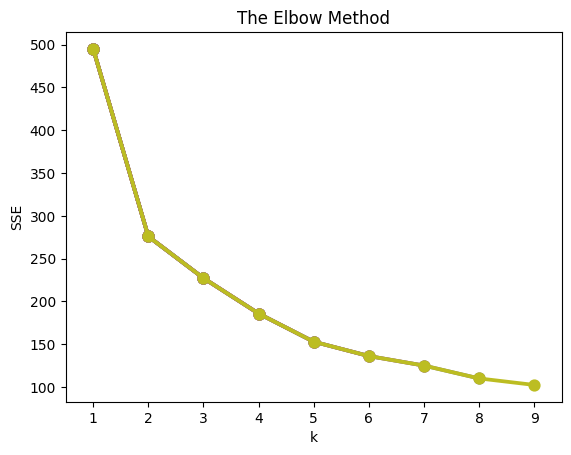

In [41]:
# F.
sse = {}
for k in range(1,10):
  kmeans = KMeans(n_clusters=k, random_state = 654)
  kmeans.fit(days25_normalized)
  sse[k] = kmeans.inertia_
  plt.title('The Elbow Method')
  plt.xlabel('k')
  plt.ylabel('SSE')
  sns.pointplot(x=list(sse.keys()), y=list(sse.values()))


As a result of this Elbow plot and additional anaysis - I will use 5 Clusters.

In [42]:
#G.
kmeans = KMeans(n_clusters=5, random_state=654)
kmeans.fit(days25_normalized)
cluster_labels = kmeans.labels_

In [43]:
#H.
days25_k5 = days25_normalized.assign(Cluster = cluster_labels)
days25_k5.groupby(['Cluster']).mean().round(2)

,Day_Tickets_Sold,Gate_Revenue,Total_Revenue,International_Visitors,High_Temperature
Cluster,,,,,
0,-0.40,-0.42,-0.39,-0.38,1.03
1,-0.52,-0.54,-0.60,-0.62,-0.58
2,4.16,4.41,4.40,-0.16,2.47
3,-0.28,-0.32,-0.39,1.83,-0.61
4,1.25,1.31,1.40,0.46,-0.15


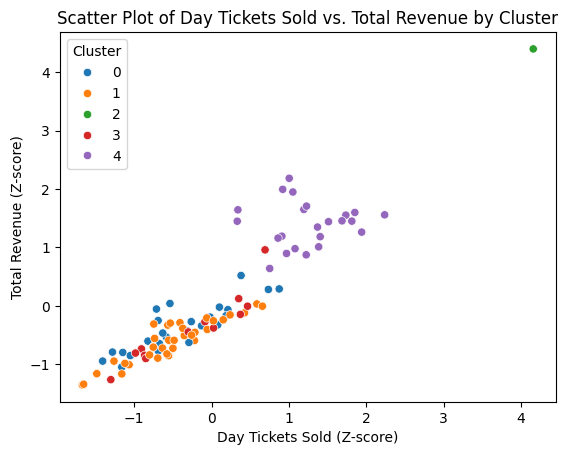

In [44]:
#I.
sns.scatterplot(data= days25_k5, x= 'Day_Tickets_Sold', y = 'Total_Revenue', hue = 'Cluster', palette='tab10')
plt.title('Scatter Plot of Day Tickets Sold vs. Total Revenue by Cluster')
plt.xlabel('Day Tickets Sold (Z-score)')
plt.ylabel('Total Revenue (Z-score)')
plt.show()

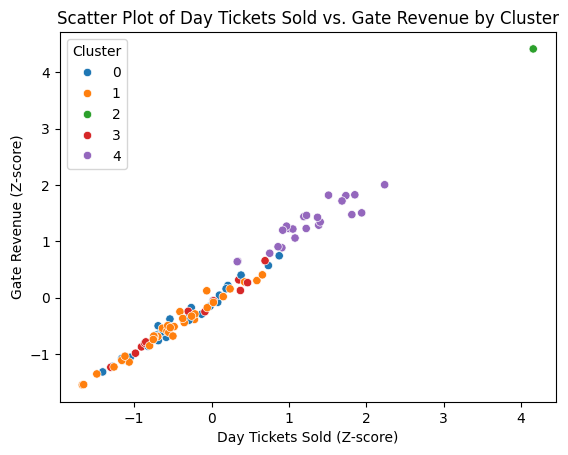

In [45]:
sns.scatterplot(data = days25_k5, x = 'Day_Tickets_Sold', y = 'Gate_Revenue', hue = 'Cluster', palette='tab10')
plt.title('Scatter Plot of Day Tickets Sold vs. Gate Revenue by Cluster')
plt.xlabel('Day Tickets Sold (Z-score)')
plt.ylabel('Gate Revenue (Z-score)')
plt.show()

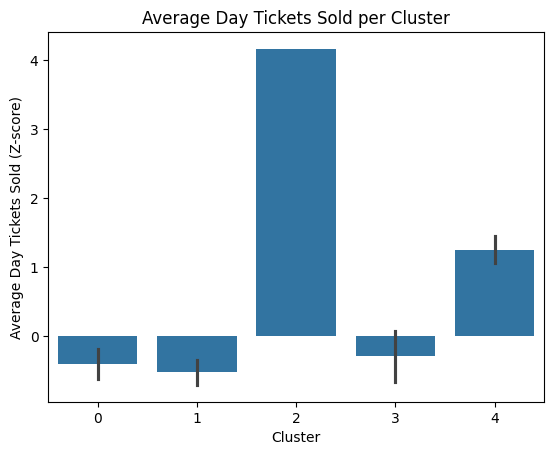

In [46]:
sns.barplot(data = days25_k5, x='Cluster', y='Day_Tickets_Sold')
plt.title('Average Day Tickets Sold per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Day Tickets Sold (Z-score)')
plt.show()

Text(0, 0.5, 'Average International Visitors (Z-score)')

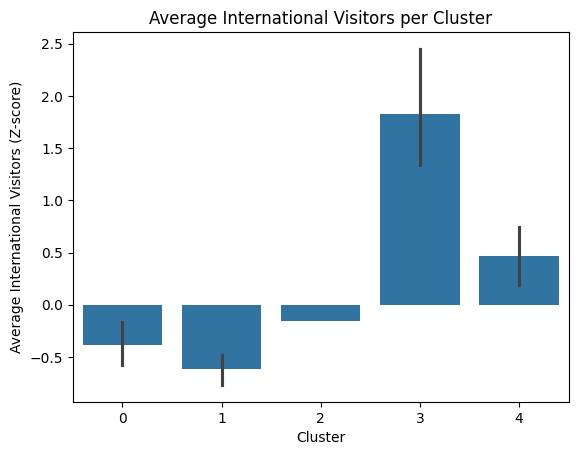

In [47]:
sns.barplot(data = days25_k5, x = 'Cluster', y= 'International_Visitors')
plt.title('Average International Visitors per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average International Visitors (Z-score)')


In [48]:
# J.
cluster_names = {
    0: "Tourist Heavy, Low Revenue Days",
    1: "Peak Performance Days",
    2: "Slump Days",
    3: "Lukewarm, Local Days",
    4: "Hot Weather Boost Days"
}

days25_k5['Cluster_Name'] = days25_k5['Cluster'].map(cluster_names)

display(days25_k5.groupby(['Cluster_Name']).mean().round(2))

,Day_Tickets_Sold,Gate_Revenue,Total_Revenue,International_Visitors,High_Temperature,Cluster
Cluster_Name,,,,,,
Hot Weather Boost Days,1.25,1.31,1.40,0.46,-0.15,4.0
"Lukewarm, Local Days",-0.28,-0.32,-0.39,1.83,-0.61,3.0
Peak Performance Days,-0.52,-0.54,-0.60,-0.62,-0.58,1.0
Slump Days,4.16,4.41,4.40,-0.16,2.47,2.0
"Tourist Heavy, Low Revenue Days",-0.40,-0.42,-0.39,-0.38,1.03,0.0


Cluster 0 → "Tourist-Heavy, Low Revenue Days", named as this is the cluster has above average international visitors, but the revenue and tickets sold are below average. The most notable difference here is that the number of international visitors is much higher than every other cluster.

Cluster 1 → "Peak Performance Days", named as this is the day where all of the revenues are above average by a significant margin. The number of international visitors on this way are also above average, with moderate weather conditions.

Cluster 2 → "Slump Days", named as this is the day where all of the variables are below average. Most significantly, tickets sold, gate revenue and total revenue are significantly below average on this day.

Cluster 3 → "Lukewarm Local Days", named this as the metrics are all very much slightly underperforming, other then the temperature being around the average. There is no spectacular features of this day, other than just being below the average.

Cluster 4 → "Hot Weather Boost Days", named this as high temperature on these days is exceptionally high,, which is in combination with high performing days across all of the other variables suggesting a significant boost in the performance of revenue and international visitors.

K.

"Tourist-Heavy, Low Revenue Days": This cluster is good to target international visitors who have travelled to Maine/New England, as they are days where international presence is high. As an international myself, I tend to feel more comfortable attending attractions that other internations have attended, so I feel this can be leveraged by lobsterland. Lobsterland should focus on targeting Internationals by promoting speficic local features, such as a Lobster-Roll and a Moxie soda with the ticket. This will attrat Internationals who are looking for a fun atmosphere with other internationals, but also to get to experience some local cuisine.

"Peak Performance Days": This cluster is good to target "Social Butterflys" or those who are chasing a busy, summer atmosphere. This is because these days are the most busy and provides "buzz" atmosphere. This target audience are people who enjoy being around others and are typically more extroverted. Lobsterland could bundle these days with live music and or additional foodstands from outside vendors. These will increase the overall experience and atmosphere, and attract those who are looking for a fun, busy, summer atmosphere. It will benefit lobsterland in addition as these visitors will embrace the experience, and provide a fun day out for a wider aray of customers. This would be one of the less specific days, and lean more towards slightly more undifferentiated mass marketing due to its pre-existing high performance. This strategy would be to continue to leverage these days and ensure that they continue to be succesful.

"Slump Days": This clusters would be good to target youth holiday camps from around the area to attend lobsterland on a slump day. Targeting youth holiday camps on this day would be good because as the park is less busy and has less international visitor so would benefit both parties; camp counselors would have less concerns about kids getting lost and is easier to manage, and lobsterland gets more visitors in on quiet days. Lobsterland can focus on targeting holiday camps by offering promotions that will include package entries, and include a lunch deal to help out with logisitics.


"Lukewarm Local Days": This cluster would be good to target local families from around Maine. Targeting local families makes sense because lobsterland will have average attendance, so it is not too busy but also provides a fun day out with good weather for the families. Lobsterland could add special family friendly attractions such as free face-painting, kid-focused shows and offer family tickets bundles. This will not only attract families, but try to attract families to come toegther, so that kids can hang out and enjoy the attractions, and act as a social scene for the parents.

"Hot Weather Boost Days": This cluster would be good to target young adults who are looking for a fun summer day out - either as an escape from the working week or college students looking for a fun day to enjoy their holidays. Targeting young adults who are seeking a summer day makes sense as they are likely looking to make the most of the summer weather as they dont get the chance to enjoy the weather during the regular working/school days. They could target this segment with a young adults beer garden, where visitors can buy tickets to the beer garden with drinks included, as well as the regular park. The beer garden could include a local dj or music artist to increase the "summer day vibes".

L.

Lobsterland can use the model to support their overall performance during the season. The model demonstrated the two successful days as "Peak Performance Days"and "Hot Weather Days", which on the whole are already very successful and are less of a concern to the management. Although there is an opportunity to continue to target or use mass marketing approaches, these are implemented to ensure that the days remain to be successful. In this instance, management can leverage the information to predict these days by increasing staffing and ensuring that their in-park operations and supply of food, beverages and merch is going to meet the increased demand that can be expected during these days. Having this information of the higher peforming, busier days is crucial as they can plan and prepare in adavance to ensure the customer experience is still as high as on a quieter day, where the operations may be under less stress. These days may also require additional security to ensure safety for all the visitors, which would need to be planned for in adavance. Additionally, for the "Hot Weather Boost Days", they can prepare additional areas for their visitors to cool down, and get out of the heat. For example, they could set up some cooling stations with fans and mist to ensure that everyone stays safe from the sun and still has a great time.

Alternatively, the clustering showed that there were three clusters of days that were either at average or underperforming. "Lukewarm Local Days", "Slump Days", and "Tourist-Heavy, Low Revenue Days". In these instances, lobsterland can focus on using the previously mentioned, specialized targeting approaches to increase ticket sales and improve revenues. Once these targeting strategies have been implemented, they can continue to follow these metrics to see any improvements in their performance. They would likely need to implement additional tracking methods such as customer surveys or use digital marketing analytics to track improvements. However, on days that they are more confident about being quieter - like the "Slump Days", with less visitors, they can reduce their staffing as they will likely require less staff to implement all of the operations in lobsterland that day. They would be able to make their operations more efficient across the these days as a result, reducing their costs for the day which may lead to increased profit margins. They can also leverage their employees skillset or comfortability working with international visitors (ex. employees who are bilingual) to ensure they are meeting the needs of the international visitors. Additionally, they could leverage data insights from their food and merch sales to see which products are most favorable with international visitors to ensure they are fully-stocked and adjust prices accordingly.





# PART II: CONJOINT ANALYSIS WITH A LINEAR MODEL

In [49]:
# A.
nightshow = pd.read_csv('night_show.csv', keep_default_na=False, na_values=[])

In [50]:
nightshow.head()

,bundleID,headliner,music_atmosphere,show_length,peak_dB_Level,crowding_index,viewing_zone,dining_bundle,re_entry,live_host,charity_tie_in,ratings
0,1,Fireworks,Pop Soundtrack,30,65,40,front plaza,None,None,Yes,Yes,4.249
1,2,Fireworks,Pop Soundtrack,30,65,40,front plaza,None,None,Yes,No/Doesn't Matter,4.689
2,3,Fireworks,Pop Soundtrack,30,65,40,front plaza,None,None,No/Doesn't Matter,Yes,7.999
3,4,Fireworks,Pop Soundtrack,30,65,40,front plaza,None,None,No/Doesn't Matter,No/Doesn't Matter,4.309
4,5,Fireworks,Pop Soundtrack,30,65,40,front plaza,None,One,Yes,Yes,6.239


In [51]:
nightshow.describe()

,bundleID,show_length,peak_dB_Level,crowding_index,ratings
count,73728.00000,73728.000000,73728.000000,73728.000000,73728.000000
mean,36864.50000,90.000000,85.000000,70.000000,5.487948
std,21283.58466,44.721663,16.330042,22.360831,2.189265
min,1.00000,30.000000,65.000000,40.000000,1.000000
25%,18432.75000,60.000000,65.000000,55.000000,3.869000
50%,36864.50000,90.000000,85.000000,70.000000,5.515000
75%,55296.25000,120.000000,105.000000,85.000000,7.110000
max,73728.00000,150.000000,105.000000,100.000000,10.000000


In [52]:
nightshow.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73728 entries, 0 to 73727
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bundleID          73728 non-null  int64  
 1   headliner         73728 non-null  object 
 2   music_atmosphere  73728 non-null  object 
 3   show_length       73728 non-null  int64  
 4   peak_dB_Level     73728 non-null  int64  
 5   crowding_index    73728 non-null  int64  
 6   viewing_zone      73728 non-null  object 
 7   dining_bundle     73728 non-null  object 
 8   re_entry          73728 non-null  object 
 9   live_host         73728 non-null  object 
 10  charity_tie_in    73728 non-null  object 
 11  ratings           73728 non-null  float64
dtypes: float64(1), int64(4), object(7)
memory usage: 6.8+ MB


B.

Numerical: Ratings

Categorical: Bundle ID, Headliner, Music Atmosphere, Show Length, Peak Decibel Level,  Crowding Index, Viewing Zone, Dining Bundle, Re-Entry, Live Host, Charity Tie In



In [53]:
nightshow.columns

Index(['bundleID', 'headliner', 'music_atmosphere', 'show_length',
       'peak_dB_Level', 'crowding_index', 'viewing_zone', 'dining_bundle',
       're_entry', 'live_host', 'charity_tie_in', 'ratings'],
      dtype='object')

In [54]:
# C.
nightshow2 = pd.get_dummies(nightshow, drop_first=True, columns = ['headliner', 'music_atmosphere', 'show_length',
       'peak_dB_Level', 'crowding_index', 'viewing_zone', 'dining_bundle',
       're_entry', 'live_host', 'charity_tie_in'])

The numeric input variables should be be dummified as they are actually a categorical representation of an option. The numbers represent a set grouping of an option rather than a continous numeric input, therefore they can be dummified for us to product a logistic regression model.

D.

If we were to just rank the bundles by average rating, we would not be able to see the difference between the different options within each column on the overall rating. The bundle rating also just shows the rating from one consumers bundle which does not provide any statistical significance. However, the conjoint analysis model allows us to look at each variable, and its different options within that to assess its impact on the consumers rating by accounting for all of the consumers bundle ratings. If we simply ranked the bundles, we would only be able to see the grouped average rating for one consumers opinion, without assessing the indiviual components impact on the average across all consumers. We are able to extract a deeper level of insight on a highly specific level as it relates to each variable, and the differing options provided to the visitors at lobsterland. It allows us to take a large dataset from all consumers, and generate insights across them all to find patterns and trends through our offerings.

In [55]:
nightshow2.head(10)

,bundleID,ratings,headliner_Drone Light Show,headliner_Fireworks,headliner_Live Musical,music_atmosphere_Pop Soundtrack,show_length_70,show_length_110,show_length_150,peak_dB_Level_85,...,viewing_zone_boardwalk,viewing_zone_castle_courtyard,viewing_zone_front plaza,dining_bundle_dessert_party,dining_bundle_meal_package,dining_bundle_snack_voucher,re_entry_One,re_entry_Unlimited,live_host_Yes,charity_tie_in_Yes
0,1,4.249,False,True,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,True,True
1,2,4.689,False,True,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
2,3,7.999,False,True,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
3,4,4.309,False,True,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
4,5,6.239,False,True,False,True,False,False,False,False,...,False,False,True,False,False,False,True,False,True,True
5,6,7.359,False,True,False,True,False,False,False,False,...,False,False,True,False,False,False,True,False,True,False
6,7,7.159,False,True,False,True,False,False,False,False,...,False,False,True,False,False,False,True,False,False,True
7,8,6.639,False,True,False,True,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
8,9,5.419,False,True,False,True,False,False,False,False,...,False,False,True,False,False,False,False,True,True,True
9,10,2.889,False,True,False,True,False,False,False,False,...,False,False,True,False,False,False,False,True,True,False


In [56]:
nightshow2.sort_values(by = 'ratings', ascending=False)

,bundleID,ratings,headliner_Drone Light Show,headliner_Fireworks,headliner_Live Musical,music_atmosphere_Pop Soundtrack,show_length_70,show_length_110,show_length_150,peak_dB_Level_85,...,viewing_zone_boardwalk,viewing_zone_castle_courtyard,viewing_zone_front plaza,dining_bundle_dessert_party,dining_bundle_meal_package,dining_bundle_snack_voucher,re_entry_One,re_entry_Unlimited,live_host_Yes,charity_tie_in_Yes
31949,31950,10.0,True,False,False,False,True,False,False,False,...,False,False,False,False,True,False,True,False,True,False
18040,18041,10.0,False,True,False,False,False,False,True,False,...,True,False,False,True,False,False,True,False,True,True
21744,21745,10.0,True,False,False,True,True,False,False,True,...,False,False,False,False,False,False,False,False,True,True
53653,53654,10.0,False,False,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
30148,30149,10.0,True,False,False,False,True,False,False,False,...,False,False,True,False,False,False,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63982,63983,1.0,False,False,False,True,False,False,True,False,...,False,False,True,True,False,False,False,True,False,True
26814,26815,1.0,True,False,False,True,False,False,True,True,...,False,True,False,False,True,False,True,False,False,True
62207,62208,1.0,False,False,False,True,False,True,False,False,...,True,False,False,True,False,False,False,True,False,False
7235,7236,1.0,False,True,False,True,False,False,True,False,...,False,True,False,False,True,False,False,True,False,False


In [57]:
nightshow2.columns

Index(['bundleID', 'ratings', 'headliner_Drone Light Show',
       'headliner_Fireworks', 'headliner_Live Musical',
       'music_atmosphere_Pop Soundtrack', 'show_length_70', 'show_length_110',
       'show_length_150', 'peak_dB_Level_85', 'peak_dB_Level_105',
       'crowding_index_60', 'crowding_index_80', 'crowding_index_100',
       'viewing_zone_boardwalk', 'viewing_zone_castle_courtyard',
       'viewing_zone_front plaza', 'dining_bundle_dessert_party',
       'dining_bundle_meal_package', 'dining_bundle_snack_voucher',
       're_entry_One', 're_entry_Unlimited', 'live_host_Yes',
       'charity_tie_in_Yes'],
      dtype='object')

In [58]:
# E.
X = nightshow2[['headliner_Drone Light Show',
       'headliner_Fireworks', 'headliner_Live Musical',
       'music_atmosphere_Pop Soundtrack', 'show_length_70', 'show_length_110',
       'show_length_150', 'peak_dB_Level_85', 'peak_dB_Level_105',
       'crowding_index_60', 'crowding_index_80', 'crowding_index_100',
       'viewing_zone_boardwalk', 'viewing_zone_castle_courtyard',
       'viewing_zone_front plaza', 'dining_bundle_dessert_party',
       'dining_bundle_meal_package', 'dining_bundle_snack_voucher',
       're_entry_One', 're_entry_Unlimited', 'live_host_Yes','charity_tie_in_Yes'  ]]
y = nightshow2['ratings']

regressor = LinearRegression()
regressor.fit(X,y)

LinearRegression()

In [59]:
regressor.intercept_

np.float64(4.953266755574281)

In [60]:
# F.

nightshow2_coef = pd.DataFrame(regressor.coef_, X.columns, columns=['Coefficient'])
nightshow2_coef

,Coefficient
headliner_Drone Light Show,0.017789
headliner_Fireworks,0.000853
headliner_Live Musical,1.029869
music_atmosphere_Pop Soundtrack,-0.713001
show_length_70,0.717907
show_length_110,0.970937
show_length_150,0.703843
peak_dB_Level_85,0.016527
peak_dB_Level_105,-0.887189
crowding_index_60,0.223038


G.

When analyzing the results at base level from the coefficient outputs, we can clearly see the most and least popular options in the bundle. The most popular options in the bundle include, the headliner being a live musical, which increases ratings by 1.02 on average. All of the show lengths in the output give a higher rating on average than the baseline of 30minutes, this was 0.7 for 70 and 150 minute shows, with the highest being 110 minutes with a 0.97 rating increase on average. Finally, when the event has a live human host as the emcee, this increased the average rating by 0.84. The least popular options in the bundle include, a music atmosphere with a pop soundtrack which decreased the average rating by -0.71 points when present in the bundle. Additionally, when the peak decibel level reaches 105, this also leads to a decrease in the average rating by -0.88 points. The crowding index of 100 lead to a decrease in points by 0.60 on average. Finally, respondents really did not like an unlimited re-entry, which caused a large decrease on average on ratings at -1.59.

However, whhen analyzing the results at a deeper level, there are some interesting findings to report to lobsterland from the coefficient inputs. The coefficients show that the visitors have little preference difference between the show lengths, other than the fact they want them to be longer than 30 minutes. There is a similar pattern with the decibel level, with the difference between 65 and 85 decibels being marginal, but a strong decrease in ratings when it reaches 105 decibels. This shows that th visitors dont mind the sound, as long as it isnt too loud. Finally, the ratings for the crowding index we can see another interesting pattern, where the coefficients show they a crowding index of 40 (smallest) and 100 (largest) are less favorable than crowding index of either 60 or 80, where we see a small increase in the average ratings. Whilst it is a small difference of only 0.22 and 0.23 respectively, it is an interesting insight as it shows that visitors prefer to be moderately busy, rather than sparse or overcrowded. This may be because they enjoy the atmosphere of the crowd, but dont want it to take away from the atmosphere because it is too crowded.

Additionally, the coefficients showed that out of all the viewing zones, the visitors clearly preferred any option other than the sandy beach, with all other viewing zones increasing the average rating. This may be because the visitors have a worse view of the event from the beach, or because they prefer to stay away from the sand when they are visiting lobsterland. For the dinning bundles, we can see that out of all the options, none of them lead to either a noticable increase or decrease in the average rating. This may be because the visitors are less focused on the food and beverages available when they are coming for the night show, as they have already eaten before attending. Finally, the charity tie-in can cause a small increase in the average rating by 0.24. This shows that visitors like the addition of the charity tie-in, but it does not drastiically change their experience of visiting the night show.

# PART III: WILDCARD: MARKETING & SEGMENTS

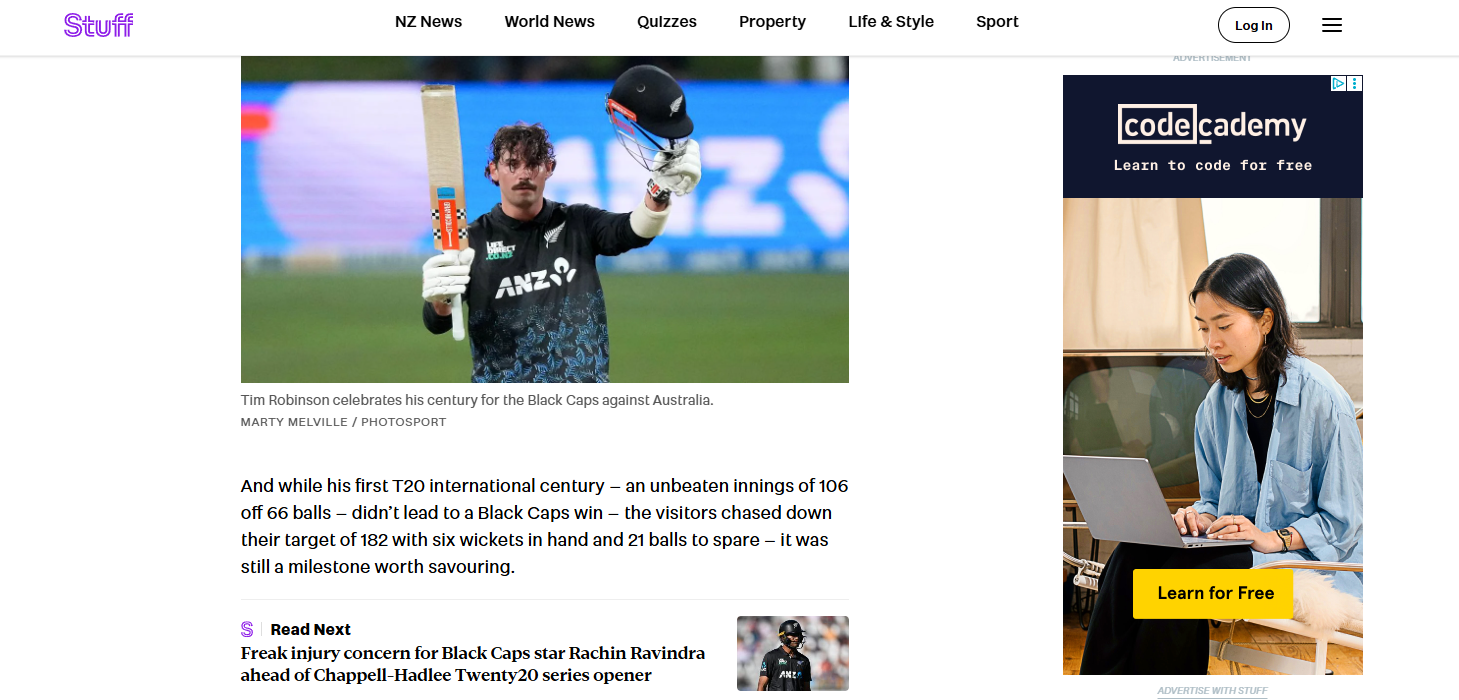


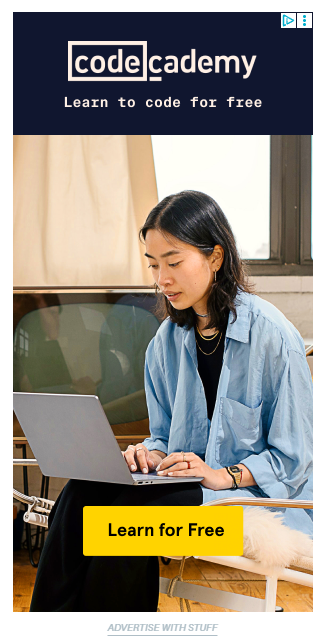

# The ad above was displayed on a news website while I was catching up with sports news from New Zealand.


I believe that the consumer segement that the ad is targeting is those who are begining to learn coding, or have shown interest in learning coding. This is because they are advertising online coding lessons for "free", which means they are trying to focus on thoses who may have a prior interest/already begun coding. Yes, I am part of this segment as I am someone who is actively learning to code and upskilling my current ability. It is likely that because this is an online ad, they have targeted my online activity where I had been researching coding prompts and information via the google, and hence why I am seeing this ad. I have mixed opinions of this ad, and I believe that its effectiveness depends on the person viewing the ads background and current situatuion. Personally, because I am actively learning to code in through my masters study, an online course ad is less effective as I am typically looking for specific answers to my problems. However, if I were to be someone who is trying to self-teach or learn to code online, this ad is likely to be much more effective as it presents itself as a platfrom to do so, and therefore is more likely to entice customers.